# MIMIC-IV → Patient Cards (v6 - Clinical Grouping)

**21 clinically-meaningful ICD groups** optimized for vital sign distinguishability.

Changes from v5:
- Replaced top-50 raw ICD codes with 21 clinical groups
- Dropped psychiatric (F-codes), symptoms (R-codes), obstetric (O-codes), and chronic conditions
- Groups based on what 12h of vitals/labs can actually distinguish
- Much better class balance (~10x max imbalance vs 1000x+ before)

Output: `patient_cards_v6_grouped.json`

## 0 · Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import importlib
for pkg in ['torch', 'numpy', 'pandas', 'tqdm', 'matplotlib']:
    print(f'  {pkg:<12} {importlib.import_module(pkg).__version__}')
print('All pre-installed packages intact.')

Mounted at /content/drive
  torch        2.10.0+cpu
  numpy        2.0.2
  pandas       2.2.2
  tqdm         4.67.3
  matplotlib   3.10.0
All pre-installed packages intact.


## 1 · Configuration

In [ ]:
import os

MIMIC_DIR = '/content/drive/MyDrive/702 project/mimic_data'          # ← root of MIMIC-IV
OUT_PATH  = '/content/drive/MyDrive/702 project/patient_cards_v6_grouped.json'

# ══════════════════════════════════════════════════════════════════════════════
# CLINICAL GROUPING: 21 classes based on what vitals can distinguish
# Dropped: psychiatric, symptoms-only, obstetric, chronic non-ICU conditions
# ══════════════════════════════════════════════════════════════════════════════
NUM_CLINICAL_GROUPS = 21  # target number of classes

# Feature selection (unchanged)
K_CHART   = 40    # top chartevents item IDs
K_LAB     = 30    # top labevents item IDs
K_INPUT   = 20    # top inputevents item IDs
K_PROC    = 15    # top procedureevents item IDs

for sub in ['hosp', 'icu']:
    p = os.path.join(MIMIC_DIR, sub)
    if not os.path.isdir(p): raise FileNotFoundError(p)
    print(f'  ✓  {p}')
print('Paths OK')

  ✓  /content/drive/MyDrive/702 project/mimic_data/hosp
  ✓  /content/drive/MyDrive/702 project/mimic_data/icu
Paths OK


## 2 · Helpers

In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

def csv_path(rel):
    full = os.path.join(MIMIC_DIR, rel)
    return full + '.gz' if os.path.exists(full + '.gz') else full

def load_csv(rel, **kw):
    p = csv_path(rel)
    print(f'  Loading {p} …')
    return pd.read_csv(p, **kw)

def stream_filter(rel, filter_col, filter_set, item_col, item_set, usecols, cs=500_000):
    p = csv_path(rel)
    print(f'  Streaming {os.path.basename(p)} …')
    chunks = []
    for chunk in tqdm(pd.read_csv(p, usecols=usecols, chunksize=cs, low_memory=False),
                      desc=os.path.basename(rel)):
        mask = chunk[filter_col].isin(filter_set)
        if item_col and item_set:
            mask &= chunk[item_col].isin(item_set)
        chunk = chunk[mask]
        if not chunk.empty:
            chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=usecols)

def stream_topk_counts(rel, filter_col, filter_set, item_col, usecols, cs=500_000):
    p = csv_path(rel)
    print(f'  Counting frequencies in {os.path.basename(p)} …')
    counts = {}
    for chunk in tqdm(pd.read_csv(p, usecols=usecols, chunksize=cs, low_memory=False),
                      desc='freq'):
        chunk = chunk[chunk[filter_col].isin(filter_set)]
        for iid, cnt in chunk[item_col].value_counts().items():
            counts[iid] = counts.get(iid, 0) + cnt
    return pd.Series(counts).sort_values(ascending=False)

print('Helpers defined ✓')

Helpers defined ✓


## 3 · Labels

In [ ]:
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# CLINICAL ICD-10 GROUPINGS - Based on actual MIMIC-IV top codes
# Optimized for what 12h of vitals/labs can distinguish
# ══════════════════════════════════════════════════════════════════════════════

# Format: 'GROUP_NAME': ['ICD10_prefix1', 'ICD10_prefix2', ...]
# Prefixes are matched from start of ICD code

ICD_CLINICAL_GROUPS = {
    # ── INFECTIOUS ────────────────────────────────────────────────────────────
    'SEPSIS': [
        'A419',   # Sepsis, unspecified organism (5,095)
        'A4151',  # Sepsis due to E. coli (1,024)
        'A4189',  # Other specified sepsis (937)
        'A40',    # Streptococcal sepsis
        'A41',    # Other sepsis
        'R6520',  # Severe sepsis without shock
        'R6521',  # Severe sepsis with shock
    ],
    'PNEUMONIA': [
        'J189',   # Pneumonia, unspecified organism (2,117)
        'J690',   # Aspiration pneumonia (828)
        'J13',    # Pneumococcal pneumonia
        'J14',    # H. influenzae pneumonia
        'J15',    # Bacterial pneumonia
        'J16',    # Other infectious pneumonia
        'J17',    # Pneumonia in diseases elsewhere
        'J18',    # Pneumonia, unspecified
    ],
    'COVID': [
        'U071',   # COVID-19 (1,937)
        'U072',   # COVID-19, virus not identified
    ],
    'UTI_INFECTION': [
        'N390',   # UTI, site not specified (2,171)
        'N10',    # Acute pyelonephritis
        'N12',    # Tubulo-interstitial nephritis
    ],
    'SKIN_SOFT_TISSUE': [
        'L03116', # Cellulitis of right lower limb (756)
        'L03115', # Cellulitis of right upper limb (675)
        'L03',    # Cellulitis and acute lymphangitis
        'L08',    # Other local skin infections
    ],

    # ── CARDIOVASCULAR ────────────────────────────────────────────────────────
    'ACUTE_MI': [
        'I214',   # NSTEMI (3,265)
        'I21',    # Acute MI (all subtypes)
        'I22',    # Subsequent MI
    ],
    'HEART_FAILURE': [
        'I130',   # Hypertensive heart+CKD with HF (3,313)
        'I110',   # Hypertensive heart disease with HF (2,459)
        'I5033',  # Acute on chronic diastolic HF (742)
        'I5023',  # Acute on chronic systolic HF (704)
        'I132',   # Hypertensive heart+CKD with HF+CKD (639)
        'I50',    # Heart failure (all subtypes)
    ],
    'CORONARY_ARTERY_DZ': [
        'I25110', # Native coronary artery disease (1,670)
        'I2510',  # Ischemic cardiomyopathy (1,482)
        'I25',    # Chronic ischemic heart disease
    ],
    'AFIB_ARRHYTHMIA': [
        'I480',   # Paroxysmal atrial fibrillation (1,055)
        'I4891',  # Unspecified atrial fibrillation (746)
        'I472',   # Ventricular tachycardia (651)
        'I48',    # Atrial fibrillation and flutter
        'I47',    # Paroxysmal tachycardia
        'I49',    # Other cardiac arrhythmias
        'I44',    # AV and left bundle-branch block
        'I45',    # Other conduction disorders
    ],
    'VALVE_DISEASE': [
        'I350',   # Aortic valve stenosis (1,342)
        'I34',    # Mitral valve disorders
        'I35',    # Aortic valve disorders
        'I36',    # Tricuspid valve disorders
        'I37',    # Pulmonary valve disorders
    ],
    'PULMONARY_EMBOLISM': [
        'I2699',  # Other pulmonary embolism (1,131)
        'I26',    # Pulmonary embolism
    ],

    # ── RESPIRATORY ───────────────────────────────────────────────────────────
    'COPD_ASTHMA': [
        'J441',   # COPD with acute exacerbation (1,131)
        'J44',    # Other COPD
        'J45',    # Asthma
        'J46',    # Status asthmaticus
    ],

    # ── NEUROLOGICAL ──────────────────────────────────────────────────────────
    'STROKE_NEURO': [
        'I671',   # Cerebral aneurysm, nonruptured (1,103)
        'I63',    # Cerebral infarction
        'I61',    # Intracerebral hemorrhage
        'I60',    # Subarachnoid hemorrhage
        'I62',    # Other nontraumatic intracranial hemorrhage
        'I64',    # Stroke, not specified
        'I67',    # Other cerebrovascular diseases
    ],
    'TRAUMA_NEURO': [
        'S065X0A', # Traumatic subdural hemorrhage (788)
        'S06',     # Intracranial injury
        'S02',     # Skull fracture
    ],
    'SYNCOPE': [
        'R55',    # Syncope and collapse (1,683)
    ],

    # ── RENAL ─────────────────────────────────────────────────────────────────
    'ACUTE_KIDNEY_INJURY': [
        'N179',   # Acute kidney failure, unspecified (2,653)
        'N17',    # Acute kidney failure
    ],

    # ── GI / HEPATIC ──────────────────────────────────────────────────────────
    'GI_BLEED': [
        'K921',   # Melena (773)
        'K922',   # GI hemorrhage, unspecified
        'K920',   # Hematemesis
        'K25',    # Gastric ulcer
        'K26',    # Duodenal ulcer
        'K27',    # Peptic ulcer
        'K28',    # Gastrojejunal ulcer
        'K62',    # Other diseases of anus/rectum (includes rectal bleeding)
    ],
    'LIVER_FAILURE': [
        'K7031',  # Alcoholic cirrhosis with ascites (1,002)
        'K70',    # Alcoholic liver disease
        'K71',    # Toxic liver disease
        'K72',    # Hepatic failure
        'K74',    # Fibrosis and cirrhosis of liver
    ],
    'PANCREATITIS': [
        'K3580',  # Acute pancreatitis without necrosis (745)
        'K85',    # Acute pancreatitis
        'K86',    # Other diseases of pancreas
    ],

    # ── TOXIC / METABOLIC ─────────────────────────────────────────────────────
    'TOXIC_METABOLIC': [
        'F10129', # Alcohol abuse with intoxication (3,447)
        'F10239', # Alcohol dependence with withdrawal (795)
        'F10229', # Alcohol dependence with intoxication (662)
        'E1165',  # DM2 with hyperglycemia (751)
        'F10',    # Alcohol related disorders
        'F11',    # Opioid related disorders
        'F12',    # Cannabis related disorders
        'F13',    # Sedative related disorders
        'F14',    # Cocaine related disorders
        'F15',    # Stimulant related disorders
        'F19',    # Other psychoactive substance disorders
        'E11',    # Type 2 diabetes with complications
        'E10',    # Type 1 diabetes with complications
        'E13',    # Other specified diabetes
        'E86',    # Volume depletion
        'E87',    # Electrolyte disorders
        'T40',    # Poisoning by narcotics
        'T43',    # Poisoning by psychotropics
    ],

    # ── SURGICAL / TRAUMA ─────────────────────────────────────────────────────
    'SURGICAL_COMPLICATION': [
        'T814XXA', # Infection following procedure (871)
        'T82868A', # Thrombosis of vascular prosthetic (669)
        'T81',     # Complications of procedures
        'T82',     # Complications of cardiac/vascular devices
        'T84',     # Complications of orthopedic devices
        'T85',     # Complications of other internal devices
    ],
}

# ══════════════════════════════════════════════════════════════════════════════
# CODES TO EXPLICITLY DROP (not distinguishable from vitals)
# ══════════════════════════════════════════════════════════════════════════════
DROP_PREFIXES = [
    # Psychiatric - vitals don't distinguish
    'F29',    # Psychosis (1,025)
    'F319',   # Bipolar disorder (661)
    'F32',    # Major depressive episode
    'F33',    # Recurrent depressive disorder
    'R45851', # Suicidal ideation (836)

    # Symptoms only - not diagnoses
    'R079',   # Chest pain, unspecified (2,906)
    'R0789',  # Other chest pain (2,120)
    'R109',   # Abdominal pain (697)
    'R42',    # Dizziness (648)

    # Obstetric - different patient population
    'O480',   # Post-term pregnancy (765)
    'O34211', # C-section scar (676)
    'O',      # All obstetric codes

    # Oncology - vitals don't distinguish tumor types
    'C7931',  # Brain metastasis (709)
    'C',      # All neoplasms (primary)
    'D',      # Neoplasms (in situ, benign, uncertain)

    # Chronic conditions - not acute ICU presentations
    'M1711',  # Osteoarthritis (666)
    'Z5111',  # Chemotherapy encounter (3,557)
    'Z',      # Factors influencing health status
]

def should_drop(icd_code):
    """Check if ICD code should be dropped."""
    icd_code = str(icd_code).strip().upper()
    for prefix in DROP_PREFIXES:
        if icd_code.startswith(prefix):
            return True
    return False

def get_clinical_group(icd_code):
    """
    Map an ICD-10 code to its clinical group.
    Returns group name or None if should be dropped/not matched.
    """
    icd_code = str(icd_code).strip().upper()

    # Check if should be dropped first
    if should_drop(icd_code):
        return None

    # Try to match to a clinical group
    for group_name, prefixes in ICD_CLINICAL_GROUPS.items():
        for prefix in prefixes:
            if icd_code.startswith(prefix):
                return group_name

    # No match - will be dropped
    return None

# ══════════════════════════════════════════════════════════════════════════════
# LOAD AND PROCESS DIAGNOSES
# ══════════════════════════════════════════════════════════════════════════════

dx = load_csv('hosp/diagnoses_icd.csv',
              usecols=['subject_id','hadm_id','seq_num','icd_code','icd_version'])

# Keep only primary diagnosis (seq_num=1) and ICD-10
dx = dx[(dx['seq_num']==1) & (dx['icd_version']==10)].copy()
dx['icd_code'] = dx['icd_code'].str.strip()

print(f'Total diagnoses before filtering: {len(dx):,}')

# Map each ICD code to its clinical group
dx['clinical_group'] = dx['icd_code'].apply(get_clinical_group)

# Count dropped
n_dropped = dx['clinical_group'].isna().sum()
print(f'Dropped (psychiatric/symptoms/obstetric/chronic): {n_dropped:,} ({n_dropped/len(dx)*100:.1f}%)')

# Keep only rows with a valid clinical group
dx = dx[dx['clinical_group'].notna()].copy()
print(f'Remaining diagnoses: {len(dx):,}')

# Show distribution
group_counts = dx['clinical_group'].value_counts()
print(f'\n{"═"*60}')
print('Clinical group distribution:')
print(f'{"═"*60}')
for group_name, count in group_counts.items():
    pct = count / len(dx) * 100
    print(f'  {group_name:<25} {count:>6,} ({pct:5.1f}%)')

# Calculate imbalance ratio
max_count = group_counts.max()
min_count = group_counts.min()
print(f'\nImbalance ratio: {max_count/min_count:.1f}x (was 1000x+)')

# Create label map from clinical groups (alphabetically sorted for consistency)
group_names = sorted(group_counts.index.tolist())
label_map = {group_name: idx for idx, group_name in enumerate(group_names)}
inv_label_map = {idx: group_name for group_name, idx in label_map.items()}

# Prepare for merge
dx_top = dx[['hadm_id', 'icd_code', 'clinical_group']].copy()

print(f'\n{"═"*60}')
print(f'Label map: {len(label_map)} clinical groups')
print(f'{"═"*60}')
for group_name, idx in sorted(label_map.items(), key=lambda x: x[1]):
    count = group_counts.get(group_name, 0)
    print(f'  {idx:2d}: {group_name:<25} (n={count:,})')

  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/diagnoses_icd.csv.gz …
Total diagnoses before filtering: 254,377
Dropped (psychiatric/symptoms/obstetric/chronic): 159,022 (62.5%)
Remaining diagnoses: 95,355

════════════════════════════════════════════════════════════
Clinical group distribution:
════════════════════════════════════════════════════════════
  TOXIC_METABOLIC           14,032 ( 14.7%)
  SEPSIS                     8,898 (  9.3%)
  HEART_FAILURE              8,367 (  8.8%)
  SURGICAL_COMPLICATION      8,072 (  8.5%)
  STROKE_NEURO               6,738 (  7.1%)
  AFIB_ARRHYTHMIA            5,677 (  6.0%)
  ACUTE_MI                   4,523 (  4.7%)
  CORONARY_ARTERY_DZ         4,520 (  4.7%)
  TRAUMA_NEURO               3,643 (  3.8%)
  PNEUMONIA                  3,592 (  3.8%)
  LIVER_FAILURE              3,580 (  3.8%)
  PANCREATITIS               3,061 (  3.2%)
  GI_BLEED                   3,024 (  3.2%)
  ACUTE_KIDNEY_INJURY        3,022 (  3.2%)
  UTI_INFECT

In [ ]:
# Show sample ICD codes per group
print('Sample ICD codes per clinical group:')
print('=' * 60)
for group_name in sorted(ICD_CLINICAL_GROUPS.keys()):
    codes_in_group = dx[dx['clinical_group'] == group_name]['icd_code'].value_counts().head(5)
    print(f'\n{group_name}:')
    for code, count in codes_in_group.items():
        print(f'  {code:<10} {count:>5,}')

Sample ICD codes per clinical group:

ACUTE_KIDNEY_INJURY:
  N179       2,653
  N170         316
  N178          52
  N172           1

ACUTE_MI:
  I214       3,265
  I2119        317
  I2109        257
  I21A1        173
  I2111        121

AFIB_ARRHYTHMIA:
  I480       1,055
  I4891        746
  I472         651
  I442         516
  I495         409

COPD_ASTHMA:
  J441       1,131
  J45901       559
  J440         166
  J4551         72
  J449          64

CORONARY_ARTERY_DZ:
  I25110     1,670
  I2510      1,482
  I25119       599
  I25118       534
  I255          79

COVID:
  U071       1,937

GI_BLEED:
  K921         773
  K922         518
  K254         311
  K264         259
  K920         257

HEART_FAILURE:
  I130       3,313
  I110       2,459
  I5033        742
  I5023        704
  I132         639

LIVER_FAILURE:
  K7031      1,002
  K7290        483
  K7469        473
  K7200        331
  K7040        241

PANCREATITIS:
  K3580        745
  K8590        611
  K8510      

## 4 · ICU Cohort

In [ ]:
icu = load_csv('icu/icustays.csv',
               usecols=['subject_id','hadm_id','stay_id','intime','outtime'])
print(icu.head())
icu['intime']    = pd.to_datetime(icu['intime'])
icu['outtime']   = pd.to_datetime(icu['outtime'])
icu['los_hours'] = (icu['outtime'] - icu['intime']).dt.total_seconds() / 3600

# Merge with diagnoses (now includes clinical_group, filtered to valid groups only)
icu = icu.merge(dx_top, on='hadm_id', how='inner')
icu = icu[icu['los_hours'] >= 12].copy()
icu['window_end']   = icu['outtime']
icu['window_start'] = icu['window_end'] - pd.Timedelta(hours=12)

stay_ids = set(icu['stay_id'])
hadm_ids = set(icu['hadm_id'])
print(f'\nFiltered to patients with ICU stay >= 12 hours')
print(f'Cohort: {len(icu):,} stays | {icu["subject_id"].nunique():,} patients')

# Show clinical group distribution in final cohort
print(f'\n{"═"*60}')
print(f'Clinical group distribution in ICU cohort:')
print(f'{"═"*60}')
cohort_groups = icu['clinical_group'].value_counts()
for group_name, count in cohort_groups.items():
    pct = count / len(icu) * 100
    print(f'  {group_name:<25} {count:>5,} ({pct:5.1f}%)')

# Check imbalance in final cohort
print(f'\nFinal imbalance ratio: {cohort_groups.max()/cohort_groups.min():.1f}x')

  Loading /content/drive/MyDrive/702 project/mimic_data/icu/icustays.csv.gz …
   subject_id   hadm_id   stay_id               intime              outtime
0    10000032  29079034  39553978  2180-07-23 14:00:00  2180-07-23 23:50:47
1    10000690  25860671  37081114  2150-11-02 19:37:00  2150-11-06 17:03:17
2    10000980  26913865  39765666  2189-06-27 08:42:00  2189-06-27 20:38:27
3    10001217  24597018  37067082  2157-11-20 19:18:02  2157-11-21 22:08:00
4    10001217  27703517  34592300  2157-12-19 15:42:24  2157-12-20 14:27:41

Filtered to patients with ICU stay >= 12 hours
Cohort: 28,467 stays | 22,097 patients

════════════════════════════════════════════════════════════
Clinical group distribution in ICU cohort:
════════════════════════════════════════════════════════════
  SEPSIS                    5,524 ( 19.4%)
  STROKE_NEURO              4,740 ( 16.7%)
  ACUTE_MI                  2,361 (  8.3%)
  CORONARY_ARTERY_DZ        2,335 (  8.2%)
  HEART_FAILURE             1,794 (  6.3%

## 5 · Item Dictionaries — the interpretability foundation

`d_items` covers `chartevents`, `inputevents`, `outputevents`, `procedureevents`.  
`d_labitems` covers `labevents`.  
We clean the labels and deduplicate so every feature has a unique human-readable name.

In [ ]:
import re

# ── d_items (ICU tables) ──────────────────────────────────────────────────────
d_items = load_csv('icu/d_items.csv')
d_items['label']    = d_items['label'].fillna('unknown')
d_items['unitname'] = d_items['unitname'].fillna('')

# ── d_labitems (lab table) ────────────────────────────────────────────────────
d_labitems = load_csv('hosp/d_labitems.csv',
                      usecols=['itemid', 'label', 'fluid', 'category'])
d_labitems['label'] = d_labitems['label'].fillna('unknown')

def clean_label(raw: str) -> str:
    """Lowercase, strip parens/units, replace spaces/hyphens with underscores."""
    s = raw.lower().strip()
    s = re.sub(r'\(.*?\)', '', s)   # remove parenthetical units: "Heart Rate (bpm)" → "Heart Rate"
    s = re.sub(r'[^a-z0-9]+', '_', s)
    s = s.strip('_')
    return s

item_label_map  = {row['itemid']: clean_label(row['label'])
                   for _, row in d_items.iterrows()}
lab_label_map   = {row['itemid']: clean_label(row['label'])
                   for _, row in d_labitems.iterrows()}


# Add to your label filtering step after building item_label_map
BLOCKLIST = {
    'h', 'l', 'i', 'a', 'b', 'c',   # single-char artifacts
    'unknown',
}
item_label_map = {iid: name for iid, name in item_label_map.items()
                  if name not in BLOCKLIST and len(name) > 2}

print(f'd_items  : {len(item_label_map):,} entries')
print(f'd_labitems: {len(lab_label_map):,} entries')
print('\nSample mappings (d_items):')
for iid, name in list(item_label_map.items())[:8]:
    print(f'  {iid} → {name}')

  Loading /content/drive/MyDrive/702 project/mimic_data/icu/d_items.csv.gz …
  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/d_labitems.csv.gz …
d_items  : 4,080 entries
d_labitems: 1,650 entries

Sample mappings (d_items):
  220001 → problem_list
  220003 → icu_admission_date
  220045 → heart_rate
  220046 → heart_rate_alarm_high
  220047 → heart_rate_alarm_low
  220048 → heart_rhythm
  220050 → arterial_blood_pressure_systolic
  220051 → arterial_blood_pressure_diastolic


In [ ]:
# Filter d_items to numeric chartevents items only
# This eliminates alarms, admin entries, categorical fields, and date stamps

d_items_numeric = d_items[
    (d_items['param_type'] == 'Numeric') &
    (d_items['linksto'] == 'chartevents')
]
VALID_CHART_IDS = set(d_items_numeric['itemid'])

print(f"d_items total          : {len(d_items):,}")
print(f"d_items numeric+chart  : {len(VALID_CHART_IDS):,}  ← use this as whitelist")
print(f"\nItems excluded (sample):")
excluded = d_items[~d_items['itemid'].isin(VALID_CHART_IDS)].head(10)
print(excluded[['itemid','label','param_type','linksto']].to_string(index=False))

d_items total          : 4,095
d_items numeric+chart  : 732  ← use this as whitelist

Items excluded (sample):
 itemid                            label    param_type          linksto
 220001                     Problem List          Text      chartevents
 220003               ICU Admission date Date and time   datetimeevents
 220048                     Heart Rhythm          Text      chartevents
 220120 Intra Aortic Ballon Pump Setting          Text      chartevents
 220341                   Alanine (ingr)    Ingredient ingredientevents
 220344                       Amino Acid    Ingredient ingredientevents
 220346                   Arachidic acid    Ingredient ingredientevents
 220347                         Arginine    Ingredient ingredientevents
 220349                    Ascorbic acid    Ingredient ingredientevents
 220351                    Aspartic Acid    Ingredient ingredientevents


## 6 · Compute Top-K Item IDs (data-driven)

In [ ]:
ce_freq = stream_topk_counts('icu/chartevents.csv',   'stay_id', stay_ids,
                              'itemid', ['stay_id','itemid'])
le_freq = stream_topk_counts('hosp/labevents.csv',    'hadm_id', hadm_ids,
                              'itemid', ['hadm_id','itemid'])
ie_freq = stream_topk_counts('icu/inputevents.csv',   'stay_id', stay_ids,
                              'itemid', ['stay_id','itemid'])
pe_freq = stream_topk_counts('icu/procedureevents.csv','stay_id', stay_ids,
                              'itemid', ['stay_id','itemid'])

# Intersect with numeric-only chartevents whitelist built in Cell 14
TOP_CHART_IDS = [iid for iid in ce_freq.index if iid in VALID_CHART_IDS][:K_CHART]
TOP_LAB_IDS   = le_freq.head(K_LAB).index.tolist()
TOP_INPUT_IDS = ie_freq.head(K_INPUT).index.tolist()
TOP_PROC_IDS  = pe_freq.head(K_PROC).index.tolist()

print(f'Top chart IDs: {len(TOP_CHART_IDS)}')
print(f'Top lab IDs  : {len(TOP_LAB_IDS)}')
print(f'Top input IDs: {len(TOP_INPUT_IDS)}')
print(f'Top proc IDs : {len(TOP_PROC_IDS)}')

  Counting frequencies in chartevents.csv.gz …


freq: 0it [00:00, ?it/s]

  Counting frequencies in labevents.csv.gz …


freq: 0it [00:00, ?it/s]

  Counting frequencies in inputevents.csv.gz …


freq: 0it [00:00, ?it/s]

  Counting frequencies in procedureevents.csv.gz …


freq: 0it [00:00, ?it/s]

Top chart IDs: 40
Top lab IDs  : 30
Top input IDs: 20
Top proc IDs : 15


## 7 · Build Interpretable Feature Names

Map each selected item ID to its human-readable label.  
Handle duplicates (e.g. two item IDs both labelled `creatinine`) by appending `_2`, `_3`.  
Result: `heart_rate_val`, `heart_rate_mask`, `norepinephrine_val`, `norepinephrine_mask`, etc.

In [ ]:
'''
def deduplicated_names(item_ids, label_map_src):
    """
    Given a list of item IDs and a {itemid: clean_name} map,
    return a list of unique names (appending _2, _3 for duplicates)
    and a dict {itemid: unique_name}.
    """
    seen   = {}
    result = {}  # itemid → unique_name
    for iid in item_ids:
        base = label_map_src.get(iid, f'item_{iid}')
        if base not in seen:
            seen[base] = 1
            result[iid] = base
        else:
            seen[base] += 1
            result[iid] = f'{base}_{seen[base]}'
    return result

CHART_NAME_MAP = deduplicated_names(TOP_CHART_IDS, item_label_map)
LAB_NAME_MAP   = deduplicated_names(TOP_LAB_IDS,   lab_label_map)
INPUT_NAME_MAP = deduplicated_names(TOP_INPUT_IDS,  item_label_map)
PROC_NAME_MAP  = deduplicated_names(TOP_PROC_IDS,   item_label_map)


# ── § 5b  Drop features with cohort-wide observation rate < MIN_OBS_RATE ──────
# We do a fast pass over a *sample* of stays (up to SAMPLE_N) to estimate
# per-item observation rates before building all cards.  Any item ID whose
# fraction of (patient × hours) that are observed falls below the threshold
# is removed from its Top-K list right here, before FEATURE_COLS is built.
#
# Why here and not after building all cards?
#   • Cheaper: we read the already-filtered DataFrames, not raw MIMIC files.
#   • Cleaner: the dropped IDs never enter FEATURE_COLS, so the LSTM never
#     sees them and card JSON stays lean.

MIN_OBS_RATE = 0.05   # drop features observed in < 5 % of (patient-hours)
SAMPLE_N     = 2000   # number of stays to sample for the rate estimate

import random
sample_sids = random.sample(sorted(stay_ids), min(SAMPLE_N, len(stay_ids)))
sample_rows = icu[icu['stay_id'].isin(sample_sids)]

def _obs_rates_point(df, sid_col, item_col, item_ids, ws_map, T=12):
    """
    For point events (chartevents, labevents): fraction of (stay × hour) slots
    that contain at least one observation per item_id.
    ws_map: {stay_id: window_start}
    """
    counts = {iid: 0 for iid in item_ids}
    total  = len(sample_sids) * T
    if df is None or df.empty:
        return {iid: 0.0 for iid in item_ids}
    sub = df[df[sid_col].isin(sample_sids) & df['itemid'].isin(item_ids)].copy()
    if sub.empty:
        return {iid: 0.0 for iid in item_ids}
    sub['ws'] = sub[sid_col].map(ws_map)
    sub = sub.dropna(subset=['ws'])
    sub['hbin'] = ((sub['charttime'] - sub['ws']).dt.total_seconds() / 3600
                   ).astype(int).clip(0, T-1)
    for (sid, hbin, iid), _ in sub.groupby([sid_col, 'hbin', 'itemid']).size().items():
        if iid in counts:
            counts[iid] += 1
    return {iid: v / total for iid, v in counts.items()}

def _obs_rates_interval(df, item_ids, ws_map, T=12):
    """
    For interval events (inputevents, procedureevents): fraction of
    (stay × hour) slots where the item is active.
    """
    counts = {iid: 0 for iid in item_ids}
    total  = len(sample_sids) * T
    if df is None or df.empty:
        return {iid: 0.0 for iid in item_ids}
    sub = df[df['stay_id'].isin(sample_sids) & df['itemid'].isin(item_ids)].copy()
    if sub.empty:
        return {iid: 0.0 for iid in item_ids}
    for sid, grp in sub.groupby('stay_id'):
        ws = ws_map.get(sid)
        if ws is None: continue
        we = ws + pd.Timedelta(hours=T)
        for _, row in grp.iterrows():
            iid = row['itemid']
            if iid not in counts: continue
            for hbin in range(T):
                bin_s = ws + pd.Timedelta(hours=hbin)
                bin_e = bin_s + pd.Timedelta(hours=1)
                if row['starttime'] < bin_e and row['endtime'] > bin_s:
                    counts[iid] += 1
    return {iid: v / total for iid, v in counts.items()}

ws_map_sid  = dict(zip(icu['stay_id'], icu['window_start']))
ws_map_hadm = {row['hadm_id']: row['window_start'] for _, row in icu.iterrows()}

ce_sample = ce[ce['stay_id'].isin(sample_sids)]
le_sample = le[le['stay_id'].isin(sample_sids)]
ie_sample = ie[ie['stay_id'].isin(sample_sids)]
pe_sample = pe[pe['stay_id'].isin(sample_sids)]

ce_rates = _obs_rates_point(ce_sample, 'stay_id', 'itemid', TOP_CHART_IDS, ws_map_sid)
le_rates = _obs_rates_point(le_sample, 'stay_id', 'itemid', TOP_LAB_IDS,   ws_map_sid)
ie_rates = _obs_rates_interval(ie_sample, TOP_INPUT_IDS, ws_map_sid)
pe_rates = _obs_rates_interval(pe_sample, TOP_PROC_IDS,  ws_map_sid)

def _apply_threshold(id_list, rate_dict, label):
    kept    = [iid for iid in id_list if rate_dict.get(iid, 0) >= MIN_OBS_RATE]
    dropped = [iid for iid in id_list if rate_dict.get(iid, 0) <  MIN_OBS_RATE]
    print(f'  {label}: kept {len(kept)}/{len(id_list)}'
          f'  (dropped {len(dropped)} below {MIN_OBS_RATE*100:.0f}%)')
    return kept

print(f'Sparse-feature drop  (threshold = {MIN_OBS_RATE*100:.0f}%,  sample = {len(sample_sids)} stays)')
TOP_CHART_IDS = _apply_threshold(TOP_CHART_IDS, ce_rates, 'chartevents')
TOP_LAB_IDS   = _apply_threshold(TOP_LAB_IDS,   le_rates, 'labevents  ')
TOP_INPUT_IDS = _apply_threshold(TOP_INPUT_IDS, ie_rates, 'inputevents')
TOP_PROC_IDS  = _apply_threshold(TOP_PROC_IDS,  pe_rates, 'procedureevents')
print('Done ✓')
# ─────────────────────────────────────────────────────────────────────────────

def make_feature_names(name_map):
    """Interleaved val/mask pairs in item_ids order."""
    names = []
    for iid, name in name_map.items():
        names.append(f'{name}_val')
        names.append(f'{name}_mask')
    return names

FEATURE_COLS = (
    make_feature_names(CHART_NAME_MAP) +
    make_feature_names(LAB_NAME_MAP)   +
    make_feature_names(INPUT_NAME_MAP) +
    make_feature_names(PROC_NAME_MAP)  +
    ['urine_output_val', 'urine_output_mask']
)

N_FEATURES = len(FEATURE_COLS)
print(f'Total feature columns: {N_FEATURES}  (= {N_FEATURES//2} features × 2)')
print('\nSample feature names:')
for f in FEATURE_COLS[:16]:
    print(f'  {f}')
print('  ...')
'''

'\ndef deduplicated_names(item_ids, label_map_src):\n    """\n    Given a list of item IDs and a {itemid: clean_name} map,\n    return a list of unique names (appending _2, _3 for duplicates)\n    and a dict {itemid: unique_name}.\n    """\n    seen   = {}\n    result = {}  # itemid → unique_name\n    for iid in item_ids:\n        base = label_map_src.get(iid, f\'item_{iid}\')\n        if base not in seen:\n            seen[base] = 1\n            result[iid] = base\n        else:\n            seen[base] += 1\n            result[iid] = f\'{base}_{seen[base]}\'\n    return result\n\nCHART_NAME_MAP = deduplicated_names(TOP_CHART_IDS, item_label_map)\nLAB_NAME_MAP   = deduplicated_names(TOP_LAB_IDS,   lab_label_map)\nINPUT_NAME_MAP = deduplicated_names(TOP_INPUT_IDS,  item_label_map)\nPROC_NAME_MAP  = deduplicated_names(TOP_PROC_IDS,   item_label_map)\n\n\n# ── § 5b  Drop features with cohort-wide observation rate < MIN_OBS_RATE ──────\n# We do a fast pass over a *sample* of stays (up to S

In [ ]:
def deduplicated_names(item_ids, label_map_src):
    seen   = {}
    result = {}
    for iid in item_ids:
        base = label_map_src.get(iid, f'item_{iid}')
        if base not in seen:
            seen[base] = 1
            result[iid] = base
        else:
            seen[base] += 1
            result[iid] = f'{base}_{seen[base]}'
    return result

CHART_NAME_MAP = deduplicated_names(TOP_CHART_IDS, item_label_map)
LAB_NAME_MAP   = deduplicated_names(TOP_LAB_IDS,   lab_label_map)
INPUT_NAME_MAP = deduplicated_names(TOP_INPUT_IDS,  item_label_map)
PROC_NAME_MAP  = deduplicated_names(TOP_PROC_IDS,   item_label_map)

# ── § 5b constants & rate helpers (filtering runs in § 5c, after tables load) ─
MIN_OBS_RATE = 0.05
SAMPLE_N     = 2000

def _obs_rates_point(df_by_sid, item_ids, ws_map, sample_sids, T=12):
    """
    For point events (chartevents, labevents): fraction of (stay × hour) slots
    that contain at least one observation per item_id.
    df_by_sid: {stay_id: df_chunk}
    ws_map: {stay_id: window_start}
    """
    counts = {iid: 0 for iid in item_ids}
    total  = len(sample_sids) * T
    for sid in sample_sids:
        df = df_by_sid.get(sid)
        if df is None or df.empty:
            continue
        ws = ws_map.get(sid)
        if ws is None:
            continue
        sub = df[df['itemid'].isin(item_ids)].copy()
        if sub.empty:
            continue
        sub['hbin'] = ((sub['charttime'] - ws).dt.total_seconds() / 3600
                       ).astype(int).clip(0, T - 1)
        for (hbin, iid), _ in sub.groupby(['hbin', 'itemid']).size().items():
            if iid in counts:
                counts[iid] += 1
    return {iid: v / total for iid, v in counts.items()}

def _obs_rates_interval(df_by_sid, item_ids, ws_map, sample_sids, T=12):
    """
    For interval events (inputevents, procedureevents): fraction of
    (stay × hour) slots where the item is active.
    """
    counts = {iid: 0 for iid in item_ids}
    total  = len(sample_sids) * T
    for sid in sample_sids:
        df = df_by_sid.get(sid)
        if df is None or df.empty:
            continue
        ws = ws_map.get(sid)
        if ws is None: continue
        we = ws + pd.Timedelta(hours=T)
        sub = df[df['itemid'].isin(item_ids)].copy()
        if sub.empty:
            continue
        for _, row in sub.iterrows():
            iid = row['itemid']
            if iid not in counts: continue
            for hbin in range(T):
                bin_s = ws + pd.Timedelta(hours=hbin)
                bin_e = bin_s + pd.Timedelta(hours=1)
                if row['starttime'] < bin_e and row['endtime'] > bin_s:
                    counts[iid] += 1
    return {iid: v / total for iid, v in counts.items()}

def _apply_threshold(id_list, rate_dict, label):
    kept    = [iid for iid in id_list if rate_dict.get(iid, 0) >= MIN_OBS_RATE]
    dropped = [iid for iid in id_list if rate_dict.get(iid, 0) <  MIN_OBS_RATE]
    print(f'  {label}: kept {len(kept)}/{len(id_list)}'
          f'  (dropped {len(dropped)} below {MIN_OBS_RATE*100:.0f}%)')
    return kept


## 8 · Load Event Tables

In [ ]:
URINE_ITEM_IDS = [226559,226560,226561,226584,226563,226564,226565,226567,226557,226558]

ce = stream_filter('icu/chartevents.csv', 'stay_id', stay_ids,
                   'itemid', set(TOP_CHART_IDS),
                   ['stay_id','itemid','charttime','valuenum'])
ce = ce[ce['valuenum'].notna()]
ce['charttime'] = pd.to_datetime(ce['charttime'])

le_raw = stream_filter('hosp/labevents.csv', 'hadm_id', hadm_ids,
                       'itemid', set(TOP_LAB_IDS),
                       ['hadm_id','itemid','charttime','valuenum'])
le_raw = le_raw[le_raw['valuenum'].notna()]
le_raw['charttime'] = pd.to_datetime(le_raw['charttime'])
le = icu[['stay_id','hadm_id']].merge(le_raw, on='hadm_id', how='inner')

oe = stream_filter('icu/outputevents.csv', 'stay_id', stay_ids,
                   'itemid', set(URINE_ITEM_IDS),
                   ['stay_id','itemid','charttime','value'])
oe = oe.rename(columns={'value':'valuenum'})
oe['valuenum']  = pd.to_numeric(oe['valuenum'], errors='coerce')
oe['charttime'] = pd.to_datetime(oe['charttime'])
oe = oe.dropna(subset=['valuenum'])

ie = stream_filter('icu/inputevents.csv', 'stay_id', stay_ids,
                   'itemid', set(TOP_INPUT_IDS),
                   ['stay_id','itemid','starttime','endtime','amount','rate'])
ie['starttime'] = pd.to_datetime(ie['starttime'])
ie['endtime']   = pd.to_datetime(ie['endtime'])
ie['amount']    = pd.to_numeric(ie['amount'], errors='coerce').fillna(0)
ie['rate']      = pd.to_numeric(ie['rate'],   errors='coerce').fillna(0)

pe = stream_filter('icu/procedureevents.csv', 'stay_id', stay_ids,
                   'itemid', set(TOP_PROC_IDS),
                   ['stay_id','itemid','starttime','endtime'])
pe['starttime'] = pd.to_datetime(pe['starttime'])
pe['endtime']   = pd.to_datetime(pe['endtime'])

print('All tables loaded.')

  Streaming chartevents.csv.gz …


chartevents.csv: 0it [00:00, ?it/s]

  Streaming labevents.csv.gz …


labevents.csv: 0it [00:00, ?it/s]

  Streaming outputevents.csv.gz …


...

  Streaming inputevents.csv.gz …


inputevents.csv: 0it [00:00, ?it/s]

  Streaming procedureevents.csv.gz …


procedureevents.csv: 0it [00:00, ?it/s]

All tables loaded.


In [ ]:
ce_by_sid = {sid: g for sid, g in ce.groupby('stay_id')}
le_by_sid = {sid: g for sid, g in le.groupby('stay_id')}
oe_by_sid = {sid: g for sid, g in oe.groupby('stay_id')}
ie_by_sid = {sid: g for sid, g in ie.groupby('stay_id')}
pe_by_sid = {sid: g for sid, g in pe.groupby('stay_id')}
print('Grouped ✓')

Grouped ✓


In [ ]:
# ── § 5c  Apply sparse-feature drop using grouped event tables ────────────────
import random

ws_map_sid = dict(zip(icu['stay_id'], icu['window_start']))
sample_sids = random.sample(sorted(stay_ids), min(SAMPLE_N, len(stay_ids)))

print(f'Sparse-feature drop  (threshold={MIN_OBS_RATE*100:.0f}%  sample={len(sample_sids)} stays)')

ce_rates = _obs_rates_point(ce_by_sid,    TOP_CHART_IDS, ws_map_sid, sample_sids)
le_rates = _obs_rates_point(le_by_sid,    TOP_LAB_IDS,   ws_map_sid, sample_sids)
ie_rates = _obs_rates_interval(ie_by_sid, TOP_INPUT_IDS, ws_map_sid, sample_sids)
pe_rates = _obs_rates_interval(pe_by_sid, TOP_PROC_IDS,  ws_map_sid, sample_sids)

TOP_CHART_IDS = _apply_threshold(TOP_CHART_IDS, ce_rates, 'chartevents    ')
TOP_LAB_IDS   = _apply_threshold(TOP_LAB_IDS,   le_rates, 'labevents      ')
TOP_INPUT_IDS = _apply_threshold(TOP_INPUT_IDS, ie_rates, 'inputevents    ')
TOP_PROC_IDS  = _apply_threshold(TOP_PROC_IDS,  pe_rates, 'procedureevents')

# Rebuild name maps and FEATURE_COLS with the pruned ID lists
CHART_NAME_MAP = deduplicated_names(TOP_CHART_IDS, item_label_map)
LAB_NAME_MAP   = deduplicated_names(TOP_LAB_IDS,   lab_label_map)
INPUT_NAME_MAP = deduplicated_names(TOP_INPUT_IDS,  item_label_map)
PROC_NAME_MAP  = deduplicated_names(TOP_PROC_IDS,   item_label_map)

def make_feature_names(name_map):
    """Interleaved val/mask pairs in item_ids order."""
    names = []
    for iid, name in name_map.items():
        names.append(f'{name}_val')
        names.append(f'{name}_mask')
    return names

FEATURE_COLS = (
    make_feature_names(CHART_NAME_MAP) +
    make_feature_names(LAB_NAME_MAP)   +
    make_feature_names(INPUT_NAME_MAP) +
    make_feature_names(PROC_NAME_MAP)  +
    ['urine_output_val', 'urine_output_mask']
)

N_FEATURES = len(FEATURE_COLS)
print(f'\nFEATURE_COLS: {N_FEATURES} columns  (= {N_FEATURES//2} features × 2)')
print('Done ✓')

Sparse-feature drop  (threshold=5%  sample=2000 stays)
  chartevents    : kept 27/40  (dropped 13 below 5%)
  labevents      : kept 29/30  (dropped 1 below 5%)
  inputevents    : kept 5/20  (dropped 15 below 5%)
  procedureevents: kept 6/15  (dropped 9 below 5%)

FEATURE_COLS: 136 columns  (= 68 features × 2)
Done ✓


## 9 · Builder Functions

### `build_hourly_matrix` — numeric tensor for LSTM
### `build_clinical_summary` — structured dict for debate agents

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TENSOR BUILDERS (same logic as v3, now using name maps)
# ─────────────────────────────────────────────────────────────────────────────

def build_hourly_matrix(df, ws, item_ids, agg='mean'):
    n = len(item_ids)
    val_arr  = np.zeros((12, n), dtype=np.float32)
    mask_arr = np.zeros((12, n), dtype=np.float32)

    if df is None or df.empty:
        return np.stack([val_arr, mask_arr], axis=2).reshape(12, n*2)

    item_idx = {iid: i for i, iid in enumerate(item_ids)}
    df = df.copy()
    df['hour_bin'] = (
        (df['charttime'] - ws).dt.total_seconds() / 3600
    ).astype(int).clip(0, 11)

    grp = (df.groupby(['hour_bin','itemid'])['valuenum'].mean()
           if agg == 'mean' else
           df.groupby(['hour_bin','itemid'])['valuenum'].sum())

    for (hbin, iid), val in grp.items():
        if iid in item_idx:
            col = item_idx[iid]
            val_arr[hbin, col]  = val
            mask_arr[hbin, col] = 1.0

    # ── Impute val columns only (mask stays untouched) ────────────────────
    # Strategy: ffill → bfill on val, so gaps carry the nearest real reading.
    # mask=0 still signals "not measured this hour" to the LSTM.
    # Only impute features that have at least one real observation —
    # a feature with zero observations across all 12 hours stays at 0.
    val_df = pd.DataFrame(val_arr)            # (12, n)
    mask_df = pd.DataFrame(mask_arr)

    # Set unobserved hours to NaN so pandas ffill/bfill can fill them
    val_df[mask_df == 0] = np.nan
    val_df = val_df.ffill().bfill()
    # Features with NO observations at all remain NaN → keep as 0
    val_arr = val_df.fillna(0.0).values.astype(np.float32)

    # Interleave
    out = np.empty((12, n*2), dtype=np.float32)
    out[:, 0::2] = val_arr
    out[:, 1::2] = mask_arr
    return out

def build_interval_matrix(df, ws, item_ids):
    """(12, len(item_ids)*2) for interval events (inputevents, procedureevents)."""
    we  = ws + pd.Timedelta(hours=12)
    n   = len(item_ids)
    val_arr  = np.zeros((12, n), dtype=np.float32)
    mask_arr = np.zeros((12, n), dtype=np.float32)
    if df is None or df.empty:
        out = np.empty((12, n*2), dtype=np.float32)
        out[:, 0::2] = val_arr
        out[:, 1::2] = mask_arr
        return out
    item_idx  = {iid: i for i, iid in enumerate(item_ids)}
    has_amount = 'amount' in df.columns
    df = df[(df['starttime'] < we) & (df['endtime'] > ws)].copy()
    for _, row in df.iterrows():
        iid = row['itemid']
        if iid not in item_idx: continue
        col = item_idx[iid]
        for hbin in range(12):
            bin_s = ws + pd.Timedelta(hours=hbin)
            bin_e = bin_s + pd.Timedelta(hours=1)
            if row['starttime'] < bin_e and row['endtime'] > bin_s:
                mask_arr[hbin, col] = 1.0
                if has_amount:
                    overlap = (min(row['endtime'], bin_e) -
                               max(row['starttime'], bin_s)).total_seconds()
                    total   = max((row['endtime'] - row['starttime']).total_seconds(), 1)
                    val_arr[hbin, col] += row['amount'] * (overlap / total)
                else:
                    val_arr[hbin, col] = 1.0
    out = np.empty((12, n*2), dtype=np.float32)
    out[:, 0::2] = val_arr
    out[:, 1::2] = mask_arr
    return out


# ─────────────────────────────────────────────────────────────────────────────
# CLINICAL SUMMARY BUILDER — for debate agents
# ─────────────────────────────────────────────────────────────────────────────

def _trend(values):
    """Classify trend from a list of observed (non-NaN) hourly values."""
    if len(values) < 2:
        return 'single_observation'
    delta = values[-1] - values[0]
    span  = max(abs(values[0]), 1e-6)
    pct   = delta / span
    if   pct >  0.10: return 'worsening'   # use clinically: rising creatinine = worsening
    elif pct < -0.10: return 'improving'
    else:             return 'stable'
    # Note: for vitals like HR, "worsening" means clinically worse, not just higher.
    # Agents should interpret trend direction in context of the feature.


def build_clinical_summary(ce_mat, le_mat, ie_mat, pe_mat, uo_mat,
                           oe_total_ml):
    """
    Build a human-readable summary dict from the hourly matrices.
    Only includes features that were actually observed (mask > 0 at least once).

    ce_mat, le_mat: (12, n*2) arrays from build_hourly_matrix
    ie_mat, pe_mat: (12, n*2) arrays from build_interval_matrix
    uo_mat        : (12, 2) urine output val+mask
    """
    def summarise_continuous(mat, name_map):
        """For chartevents / labevents: mean/min/max/last + trend per feature."""
        result = {}
        names  = list(name_map.values())
        n = len(names)
        val_arr  = mat[:, 0::2]   # (12, n)
        mask_arr = mat[:, 1::2]   # (12, n)
        for i, name in enumerate(names):
            observed_hours = np.where(mask_arr[:, i] > 0)[0]
            if len(observed_hours) == 0:
                continue  # never measured — skip entirely
            obs_vals = val_arr[observed_hours, i].tolist()
            result[name] = {
                'mean':  round(float(np.mean(obs_vals)), 2),
                'min':   round(float(np.min(obs_vals)),  2),
                'max':   round(float(np.max(obs_vals)),  2),
                'last':  round(float(obs_vals[-1]),      2),
                'first': round(float(obs_vals[0]),       2),
                'trend': _trend(obs_vals),
                'n_observations': len(obs_vals),
            }
        return result

    def summarise_interventions(mat, name_map):
        """For inputevents / procedureevents: list of active item names."""
        active  = []
        names   = list(name_map.values())
        mask_arr = mat[:, 1::2]   # (12, n)
        for i, name in enumerate(names):
            if mask_arr[:, i].sum() > 0:
                active.append(name)
        return active

    # Urine output
    uo_obs_hours = np.where(uo_mat[:, 1] > 0)[0]
    uo_total = float(uo_mat[:, 0].sum())  # already hourly sums

    # Vital monitoring coverage
    # fraction of hours where at least one chartevents feature was observed
    chart_mask = ce_mat[:, 1::2]   # (12, K_CHART)
    pct_monitored = float((chart_mask.sum(axis=1) > 0).mean())

    return {
        'vitals': summarise_continuous(ce_mat, CHART_NAME_MAP),
        'labs':   summarise_continuous(le_mat, LAB_NAME_MAP),
        'interventions': {
            'active_drugs':      summarise_interventions(ie_mat, INPUT_NAME_MAP),
            'active_procedures': summarise_interventions(pe_mat, PROC_NAME_MAP),
            'urine_output_total_ml': round(uo_total, 1),
        },
        'observation_hours':    12,
        'pct_hours_monitored':  round(pct_monitored, 2),
    }


print('Builder functions defined ✓')

Builder functions defined ✓


## 10 · Build Patient Cards

In [ ]:
def build_patient_card(row, ce_h, le_h, oe_h, ie_h, pe_h):
    ws = row['window_start']
    we = row['window_end']

    def tf(df, tc='charttime'):
        return df[(df[tc] >= ws) & (df[tc] <= we)] if df is not None and not df.empty else None

    def tf_interval(df):
        return df[(df['starttime'] < we) & (df['endtime'] > ws)] if df is not None and not df.empty else None

    # ── Hourly matrices (for LSTM) ────────────────────────────────────────────
    ce_mat = build_hourly_matrix(tf(ce_h), ws, TOP_CHART_IDS, agg='mean')
    le_mat = build_hourly_matrix(tf(le_h), ws, TOP_LAB_IDS,   agg='mean')
    ie_mat = build_interval_matrix(tf_interval(ie_h), ws, TOP_INPUT_IDS)
    pe_mat = build_interval_matrix(tf_interval(pe_h), ws, TOP_PROC_IDS)

    # Urine output — sum all catheter item IDs into one val+mask pair
    oe_full = build_hourly_matrix(tf(oe_h), ws, URINE_ITEM_IDS, agg='sum')
    uo_val  = oe_full[:, 0::2].sum(axis=1, keepdims=True)
    uo_mask = (oe_full[:, 1::2].sum(axis=1) > 0).astype(np.float32).reshape(12, 1)
    uo_mat  = np.concatenate([uo_val, uo_mask], axis=1)   # (12, 2)

    # ── Full time-series tensor: concatenate all blocks ───────────────────────
    ts_arr = np.concatenate([ce_mat, le_mat, ie_mat, pe_mat, uo_mat], axis=1)

    # ── Clinical summary (for debate agents) ─────────────────────────────────
    summary = build_clinical_summary(ce_mat, le_mat, ie_mat, pe_mat, uo_mat,
                                     uo_val.sum())

    return {
        # PyHealth standard fields
        'patient_id':       str(int(row['subject_id'])),
        'visit_id':         str(int(row['hadm_id'])),
        'stay_id':          str(int(row['stay_id'])),
        'conditions':       [],
        'procedures':       [],     # patched below
        'drugs':            [],     # patched below
        # LSTM input
        'time_series':      ts_arr.tolist(),
        'feature_names':    FEATURE_COLS,
        # Label - CLINICAL GROUP (not raw ICD)
        'label':            label_map[row['clinical_group']],
        'clinical_group':   row['clinical_group'],
        'icd_code':         row['icd_code'],  # preserve original for debate agents
        # Debate agent input
        'clinical_summary': summary,
    }

print('build_patient_card() defined ✓')

build_patient_card() defined ✓


In [ ]:
cards, skipped = [], []

for _, row in tqdm(icu.iterrows(), total=len(icu), desc='Building cards'):
    sid = row['stay_id']
    try:
        cards.append(build_patient_card(
            row,
            ce_by_sid.get(sid), le_by_sid.get(sid),
            oe_by_sid.get(sid), ie_by_sid.get(sid),
            pe_by_sid.get(sid),
        ))
    except Exception as exc:
        skipped.append((sid, str(exc)))

print(f'Cards built: {len(cards):,}  |  skipped: {len(skipped):,}')
if skipped:
    for sid, err in skipped[:5]: print(f'  {sid}: {err}')

Building cards:   0%|          | 0/28467 [00:00<?, ?it/s]

Cards built: 28,467  |  skipped: 0


## 11 · Patch Procedures & Drugs

In [ ]:
proc_icd = load_csv('hosp/procedures_icd.csv', usecols=['hadm_id','icd_code','icd_version'])
proc_icd = proc_icd[proc_icd['icd_version']==10]
proc_icd['icd_code'] = proc_icd['icd_code'].str.strip()
proc_by_hadm = proc_icd.groupby('hadm_id')['icd_code'].apply(list).to_dict()

rx = load_csv('hosp/prescriptions.csv', usecols=['hadm_id','drug'])
rx['drug'] = rx['drug'].str.strip().str.lower()
rx = rx.dropna(subset=['drug'])
rx_by_hadm = rx.groupby('hadm_id')['drug'].apply(lambda x: sorted(set(x))).to_dict()

for card in cards:
    hid = int(card['visit_id'])
    card['procedures'] = proc_by_hadm.get(hid, [])
    card['drugs']      = rx_by_hadm.get(hid,   [])

s = cards[0]
print(f"procedures ({len(s['procedures'])}): {s['procedures'][:4]}")
print(f"drugs      ({len(s['drugs'])}): {s['drugs'][:4]}")

  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/procedures_icd.csv.gz …
  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/prescriptions.csv.gz …
procedures (0): []
drugs      (56): ['0.9% sodium chloride', '5% dextrose', 'acetaminophen iv', 'albuterol inhaler']


In [ ]:
# See what versions exist for your cohort's admissions
proc_all = load_csv('hosp/procedures_icd.csv',
                    usecols=['hadm_id', 'icd_code', 'icd_version'])
proc_cohort = proc_all[proc_all['hadm_id'].isin(hadm_ids)]

print(proc_cohort['icd_version'].value_counts())
print(f"\nAdmissions with any procedure    : {proc_cohort['hadm_id'].nunique():,}")
print(f"Admissions with ICD-10 procedure : {proc_cohort[proc_cohort['icd_version']==10]['hadm_id'].nunique():,}")
print(f"Admissions with ICD-9  procedure : {proc_cohort[proc_cohort['icd_version']==9]['hadm_id'].nunique():,}")
print(f"Total cohort admissions          : {len(hadm_ids):,}")

  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/procedures_icd.csv.gz …
icd_version
10    101115
Name: count, dtype: int64

Admissions with any procedure    : 21,058
Admissions with ICD-10 procedure : 21,058
Admissions with ICD-9  procedure : 0
Total cohort admissions          : 25,683


In [ ]:
import numpy as np

ts         = np.array(cards[0]['time_series'])
feat_names = cards[0]['feature_names']

# Procedure keywords as whole-word matches, not substrings
PROC_KEYWORDS = ['ventilation', 'dialysis', 'arterial_line',
                 'central_line', 'catheter', 'intubat']

print(f"hadm_id : {cards[0]['visit_id']}")
print(f"stay_id : {cards[0]['stay_id']}")
print(f"ICD code: {cards[0]['icd_code']}")
print(f"procedures (ICD-PCS): {cards[0]['procedures']}")

print(f"\nActive procedure flags in time_series:")
found = False
for i, name in enumerate(feat_names):
    # Only look at _val columns, match whole keywords with word boundaries
    if not name.endswith('_val'):
        continue
    base = name.replace('_val', '')
    if not any(kw in base for kw in PROC_KEYWORDS):
        continue
    # Use the paired mask column (always val_idx + 1)
    mask_col  = i + 1
    hours_active = int(ts[:, mask_col].sum())   # count of hours observed
    if hours_active > 0:
        print(f"  {base:<35} active in {hours_active} / 12 hours")
        found = True

if not found:
    print("  (none matched — check your TOP_PROC_IDS resolved names)")
    print("\n  All _val features with mask > 0:")
    for i, name in enumerate(feat_names):
        if name.endswith('_val'):
            mask_col = i + 1
            if ts[:, mask_col].sum() > 0:
                print(f"    {name}")

hadm_id : 26133978
stay_id : 39698942
ICD code: A419
procedures (ICD-PCS): []

Active procedure flags in time_series:
  (none matched — check your TOP_PROC_IDS resolved names)

  All _val features with mask > 0:
    heart_rate_val
    respiratory_rate_val
    o2_saturation_pulseoxymetry_val
    non_invasive_blood_pressure_systolic_val
    non_invasive_blood_pressure_diastolic_val
    non_invasive_blood_pressure_mean_val
    temperature_fahrenheit_val
    glucose_finger_stick_val
    inspired_o2_fraction_val
    sodium_val
    hemoglobin_val
    chloride_val
    anion_gap_val
    h_val
    l_val
    i_val
    potassium_val
    sodium_val
    chloride_val
    creatinine_val
    urea_nitrogen_val
    bicarbonate_val
    anion_gap_val
    glucose_val
    magnesium_val
    hematocrit_val
    hemoglobin_val
    platelet_count_val
    white_blood_cells_val
    mch_val
    mcv_val
    rdw_val
    mchc_val
    red_blood_cells_val
    rdw_sd_val
    phosphate_val
    calcium_total_val
    ptt_va

In [ ]:
print("TOP_PROC_IDS resolved names:")
for iid in TOP_PROC_IDS:
    print(f"  {iid:>7}  {PROC_NAME_MAP.get(iid, '???')}")

TOP_PROC_IDS resolved names:
   224275  20_gauge
   224277  18_gauge
   229351  foley_catheter
   225752  arterial_line
   224274  22_gauge
   224263  multi_lumen


## 12 · Inspect a Clinical Summary

In [ ]:
import json, pprint

sample = cards[0]
print(f"Patient  : {sample['patient_id']}  |  stay: {sample['stay_id']}")
print(f"Label    : {sample['icd_code']}  (index {sample['label']})")
print(f"TS shape : {len(sample['time_series'])} × {len(sample['time_series'][0])}")
print()
print('── clinical_summary ──────────────────────────────')
pprint.pprint(sample['clinical_summary'], width=80, depth=3)

Patient  : 10001843  |  stay: 39698942
Label    : A419  (index 12)
TS shape : 12 × 136

── clinical_summary ──────────────────────────────
{'interventions': {'active_drugs': [],
                   'active_procedures': [],
                   'urine_output_total_ml': 55.0},
 'labs': {'anion_gap': {'first': 16.0,
                        'last': 16.0,
                        'max': 16.0,
                        'mean': 16.0,
                        'min': 16.0,
                        'n_observations': 1,
                        'trend': 'single_observation'},
          'bicarbonate': {'first': 20.0,
                          'last': 20.0,
                          'max': 20.0,
                          'mean': 20.0,
                          'min': 20.0,
                          'n_observations': 1,
                          'trend': 'single_observation'},
          'calcium_total': {'first': 8.2,
                            'last': 8.2,
                            'max': 8.2,
          

In [ ]:
def summary_to_text(card):
    """
    Convert clinical_summary to a natural language paragraph.
    This is the text a debate agent would receive as its 'evidence' block.
    """
    s   = card['clinical_summary']
    out = []

    # Vitals
    vitals_lines = []
    for feat, stats in s['vitals'].items():
        vitals_lines.append(
            f"{feat.replace('_', ' ')}: mean={stats['mean']}, "
            f"range=[{stats['min']}–{stats['max']}], "
            f"last={stats['last']} ({stats['trend']})"
        )
    if vitals_lines:
        out.append('Vitals over last 12 hrs:\n  ' + '\n  '.join(vitals_lines))

    # Labs
    lab_lines = []
    for feat, stats in s['labs'].items():
        lab_lines.append(
            f"{feat.replace('_', ' ')}: mean={stats['mean']}, "
            f"range=[{stats['min']}–{stats['max']}], "
            f"last={stats['last']} ({stats['trend']})"
        )
    if lab_lines:
        out.append('Labs:\n  ' + '\n  '.join(lab_lines))

    # Interventions
    iv  = s['interventions']
    if iv['active_drugs']:
        out.append('Active drugs: ' + ', '.join(iv['active_drugs']))
    if iv['active_procedures']:
        out.append('Active procedures: ' + ', '.join(iv['active_procedures']))
    out.append(f"Urine output: {iv['urine_output_total_ml']} mL total")
    out.append(f"Monitoring coverage: {s['pct_hours_monitored']*100:.0f}% of hours")

    return '\n\n'.join(out)


print('=' * 60)
print('DEBATE AGENT EVIDENCE BLOCK (sample patient)')
print('=' * 60)
print(summary_to_text(cards[0]))

DEBATE AGENT EVIDENCE BLOCK (sample patient)
Vitals over last 12 hrs:
  heart rate: mean=119.5, range=[90.0–136.0], last=116.0 (worsening)
  respiratory rate: mean=21.0, range=[16.0–27.0], last=27.0 (worsening)
  o2 saturation pulseoxymetry: mean=94.86, range=[84.0–99.0], last=97.0 (stable)
  non invasive blood pressure systolic: mean=81.25, range=[72.0–99.0], last=76.0 (stable)
  non invasive blood pressure diastolic: mean=52.38, range=[27.0–66.0], last=53.0 (stable)
  non invasive blood pressure mean: mean=59.0, range=[34.0–73.0], last=58.0 (stable)
  temperature fahrenheit: mean=97.5, range=[97.5–97.5], last=97.5 (single_observation)
  glucose finger stick: mean=62.0, range=[62.0–62.0], last=62.0 (single_observation)
  inspired o2 fraction: mean=40.0, range=[40.0–40.0], last=40.0 (stable)
  sodium: mean=137.0, range=[137.0–137.0], last=137.0 (single_observation)
  hemoglobin: mean=9.1, range=[9.1–9.1], last=9.1 (single_observation)
  chloride: mean=101.0, range=[101.0–101.0], last=1

## 13 · Quality Checks

X: (28467, 12, 136)  |  y: (28467,)  |  21 classes


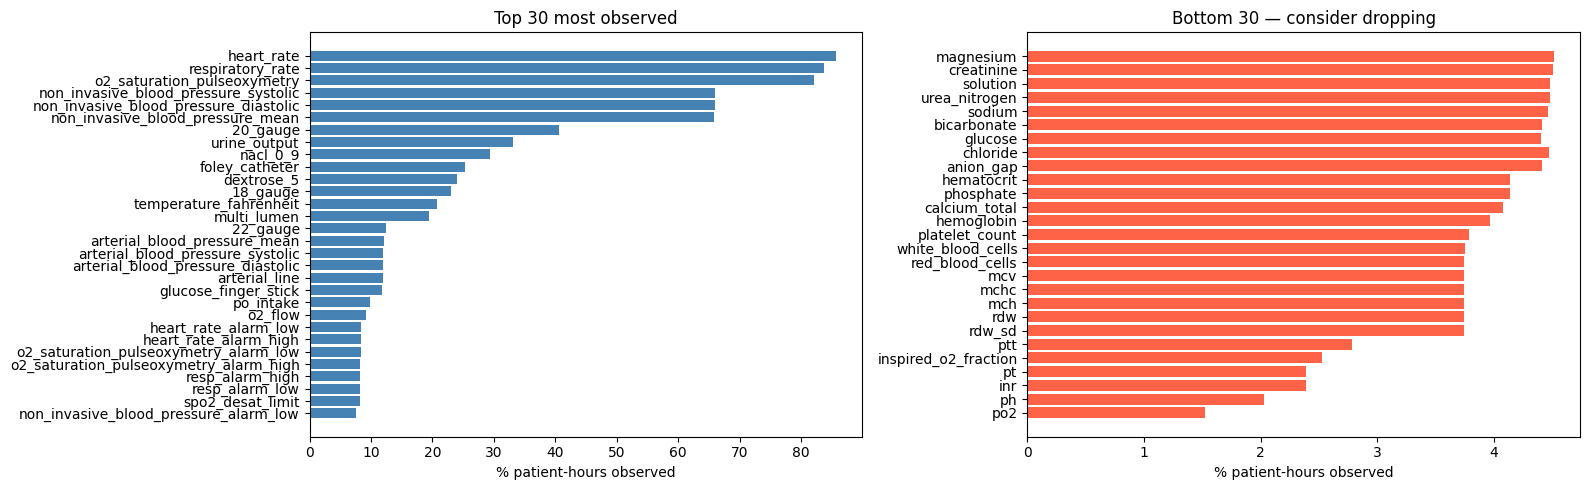


Overall observation density : 14.4%  (was 3.8% before feature reduction)
Feature columns             : 136  (was 402 before reduction)

Clinical summary coverage:
  Has vitals data     : 28,415 / 28,467
  Has lab data        : 18,001 / 28,467
  Has active drugs    : 21,146 / 28,467
  Has active procedures: 20,973 / 28,467


In [ ]:
import numpy as np, matplotlib.pyplot as plt

X = np.array([c['time_series'] for c in cards])  # (N, 12, F)
y = np.array([c['label']       for c in cards])
print(f'X: {X.shape}  |  y: {y.shape}  |  {len(np.unique(y))} classes')

mask_idx   = [i for i, n in enumerate(FEATURE_COLS) if n.endswith('_mask')]
obs_rate   = X[:, :, mask_idx].mean(axis=(0, 1))
feat_names = [FEATURE_COLS[i].replace('_mask','') for i in mask_idx]

order  = np.argsort(obs_rate)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top30 = order[:30]
axes[0].barh([feat_names[i] for i in top30][::-1],
             obs_rate[top30][::-1]*100, color='steelblue')
axes[0].set_xlabel('% patient-hours observed')
axes[0].set_title('Top 30 most observed')
bot30 = order[-30:]
axes[1].barh([feat_names[i] for i in bot30][::-1],
             obs_rate[bot30][::-1]*100, color='tomato')
axes[1].set_xlabel('% patient-hours observed')
axes[1].set_title('Bottom 30 — consider dropping')
plt.tight_layout(); plt.show()

# Summary coverage stats
n_vitals  = sum(1 for c in cards if c['clinical_summary']['vitals'])
n_labs    = sum(1 for c in cards if c['clinical_summary']['labs'])
n_drugs   = sum(1 for c in cards if c['clinical_summary']['interventions']['active_drugs'])
n_procs   = sum(1 for c in cards if c['clinical_summary']['interventions']['active_procedures'])
# ── Sparsity headline ────────────────────────────────────────────────────────
overall_obs_rate = X[:, :, mask_idx].mean()
print(f'\nOverall observation density : {overall_obs_rate*100:.1f}%  '
      f'(was 3.8% before feature reduction)')
print(f'Feature columns             : {X.shape[2]}  '
      f'(was 402 before reduction)')
print(f'\nClinical summary coverage:')
print(f'  Has vitals data     : {n_vitals:,} / {len(cards):,}')
print(f'  Has lab data        : {n_labs:,} / {len(cards):,}')
print(f'  Has active drugs    : {n_drugs:,} / {len(cards):,}')
print(f'  Has active procedures: {n_procs:,} / {len(cards):,}')

**Example card**

In [ ]:
import numpy as np
import json

# ── Pull everything from cards[0] ────────────────────────────────────────────
card         = cards[0]
ts           = np.array(card['time_series'])          # (12, F)
feat_names   = card['feature_names']
n_timesteps, n_cols = ts.shape
n_features   = n_cols // 2                            # each feature = val + mask

# Separate val and mask matrices
val_mat  = ts[:, 0::2]   # (12, n_features)
mask_mat = ts[:, 1::2]   # (12, n_features)

# Base names (strip _val / _mask suffix)
base_names = [f.replace('_val','').replace('_mask','')
              for f in feat_names[0::2]]

# Features that have at least one observed hour
observed_idx   = [i for i in range(n_features) if mask_mat[:, i].sum() > 0]
observed_names = [base_names[i] for i in observed_idx]

print("=" * 60)
print(f"Patient  : {card['patient_id']}  |  stay: {card['stay_id']}")
print(f"ICD code : {card['icd_code']}  (label {card['label']})")
print(f"Tensor   : {ts.shape}  →  LSTM input (T=12, F={n_cols})")
print(f"Features : {n_features} total  |  {len(observed_idx)} observed  |  "
      f"{n_features - len(observed_idx)} all-zero")
print("=" * 60)

# ── Per-feature observation table ────────────────────────────────────────────
print(f"\n{'feature':<45} {'obs hrs':>7}  {'mean val':>10}  {'min':>8}  {'max':>8}")
print("-" * 85)
for i in observed_idx:
    hrs     = mask_mat[:, i]
    obs_h   = int(hrs.sum())
    obs_vals = val_mat[:, i][mask_mat[:, i] > 0]
    print(f"  {base_names[i]:<43} {obs_h:>5}/12  "
          f"{obs_vals.mean():>10.2f}  "
          f"{obs_vals.min():>8.2f}  "
          f"{obs_vals.max():>8.2f}")

# ── Hour-by-hour raw tensor (first 8 observed features) ──────────────────────
print(f"\n--- Hour-by-hour tensor (first 8 observed features) ---")
show_idx = observed_idx[:8]
header = f"{'hr':>4} | " + " | ".join(f"{observed_names[i][:12]:>14}" for i in range(len(show_idx)))
print(header)
print("-" * len(header))
for h in range(12):
    row = f" h{h:02d} | "
    for i in show_idx:
        v = val_mat[h, i]
        m = int(mask_mat[h, i])
        cell = f"{v:>12.2f}{'*' if m else ' '}"
        row += f" {cell} |"
    print(row)
print("  (* = observed this hour, blank = mask=0)")

# ── Sparsity summary ─────────────────────────────────────────────────────────
overall_obs_rate = mask_mat.mean()
print(f"\nOverall observation density : {overall_obs_rate*100:.1f}% of (hours × features)")
print(f"Urine output total          : "
      f"{val_mat[:, base_names.index('urine_output')].sum():.1f} mL"
      if 'urine_output' in base_names else "")

# ── PyHealth LSTM compatibility check ────────────────────────────────────────
print("\n--- PyHealth LSTM compatibility ---")
print(f"  time_series type    : {type(card['time_series']).__name__}")
print(f"  time_series[0] type : {type(card['time_series'][0]).__name__}")
print(f"  time_series[0][0]   : {type(card['time_series'][0][0]).__name__}  = "
      f"{card['time_series'][0][0]:.4f}")
print(f"  label type          : {type(card['label']).__name__}  = {card['label']}")
print(f"  All values finite   : {np.isfinite(ts).all()}")
print(f"  Masks all in {{0,1}}  : {np.isin(mask_mat, [0,1]).all()}")
print(f"  Val cols even index : {all(ts[:,i*2].mean() >= 0 for i in range(n_features))}")
print(f"  Mask cols odd index : {all(np.isin(ts[:,i*2+1],[0,1]).all() for i in range(n_features))}")
print("  LSTM-ready          : OK" if (
    np.isfinite(ts).all() and
    np.isin(mask_mat,[0,1]).all() and
    isinstance(card['label'], int)
) else "  WARNING: check above")

Patient  : 10001843  |  stay: 39698942
ICD code : A419  (label 12)
Tensor   : (12, 136)  →  LSTM input (T=12, F=136)
Features : 68 total  |  43 observed  |  25 all-zero

feature                                       obs hrs    mean val       min       max
-------------------------------------------------------------------------------------
  heart_rate                                      8/12      119.50     90.00    136.00
  respiratory_rate                                8/12       21.00     16.00     27.00
  o2_saturation_pulseoxymetry                     7/12       94.86     84.00     99.00
  non_invasive_blood_pressure_systolic            8/12       81.25     72.00     99.00
  non_invasive_blood_pressure_diastolic           8/12       52.38     27.00     66.00
  non_invasive_blood_pressure_mean                8/12       59.00     34.00     73.00
  temperature_fahrenheit                          1/12       97.50     97.50     97.50
  glucose_finger_stick                           

In [ ]:
# Emit card data as JSON for the visualiser
import json

viz_data = {
    'patient_id': card['patient_id'],
    'icd_code':   card['icd_code'],
    'label':      card['label'],
    'shape':      list(ts.shape),
    'obs_names':  observed_names,
    'val_rows':   [[round(float(val_mat[h,i]),3) for i in observed_idx] for h in range(12)],
    'mask_rows':  [[int(mask_mat[h,i])           for i in observed_idx] for h in range(12)],
    'summary':    card['clinical_summary'],
}
print(json.dumps(viz_data, indent=2)[:3000], "\n... (truncated for display)")

{
  "patient_id": "10001843",
  "icd_code": "A419",
  "label": 12,
  "shape": [
    12,
    136
  ],
  "obs_names": [
    "heart_rate",
    "respiratory_rate",
    "o2_saturation_pulseoxymetry",
    "non_invasive_blood_pressure_systolic",
    "non_invasive_blood_pressure_diastolic",
    "non_invasive_blood_pressure_mean",
    "temperature_fahrenheit",
    "glucose_finger_stick",
    "inspired_o2_fraction",
    "sodium",
    "hemoglobin",
    "chloride",
    "anion_gap",
    "h",
    "l",
    "i",
    "potassium",
    "sodium",
    "chloride",
    "creatinine",
    "urea_nitrogen",
    "bicarbonate",
    "anion_gap",
    "glucose",
    "magnesium",
    "hematocrit",
    "hemoglobin",
    "platelet_count",
    "white_blood_cells",
    "mch",
    "mcv",
    "rdw",
    "mchc",
    "red_blood_cells",
    "rdw_sd",
    "phosphate",
    "calcium_total",
    "ptt",
    "ph",
    "pt",
    "inr",
    "po2",
    "urine_output"
  ],
  "val_rows": [
    [
      90.0,
      16.0,
      96.0,
      

## 14 · Save

In [ ]:
import json
from collections import Counter

output = {
    'label_map':     label_map,  # group_name → int
    'inv_label_map': inv_label_map,  # int → group_name
    'group_definitions': ICD_CLINICAL_GROUPS,  # group → list of ICD prefixes
    'feature_names': FEATURE_COLS,
    'n_features':    len(FEATURE_COLS),
    'n_timesteps':   12,
    'n_classes':     len(label_map),
    # Full vocab for interpretability / SHAP post-hoc
    'item_vocab': {
        'chartevents':      {str(k): v for k, v in CHART_NAME_MAP.items()},
        'labevents':        {str(k): v for k, v in LAB_NAME_MAP.items()},
        'inputevents':      {str(k): v for k, v in INPUT_NAME_MAP.items()},
        'procedureevents':  {str(k): v for k, v in PROC_NAME_MAP.items()},
    },
    'patients': cards,
}

with open(OUT_PATH, 'w') as f:
    json.dump(output, f)

size_mb = os.path.getsize(OUT_PATH) / 1e6
X_final = np.array([c['time_series'] for c in cards])
print(f'Saved → {OUT_PATH}  ({size_mb:.1f} MB)')
print(f'LSTM input shape : {X_final.shape}  (N × T=12 × F={X_final.shape[2]})')
print(f'Number of classes: {len(label_map)} clinical groups')
print(f'Each card also has clinical_summary for debate agents.')

# Final distribution check
label_counts = Counter(c['label'] for c in cards)
print(f'\n{"═"*60}')
print(f'Final label distribution:')
print(f'{"═"*60}')
for label_idx in sorted(label_counts.keys()):
    group_name = inv_label_map[label_idx]
    count = label_counts[label_idx]
    pct = count / len(cards) * 100
    print(f'  {label_idx:2d} {group_name:<25} {count:>5,} ({pct:5.1f}%)')

# Final stats
max_count = max(label_counts.values())
min_count = min(label_counts.values())
print(f'\nFinal imbalance: {max_count/min_count:.1f}x')
print(f'Total samples: {len(cards):,}')

Saved → /content/drive/MyDrive/702 project/patient_cards_v6_grouped.json  (519.2 MB)
LSTM input shape : (28467, 12, 136)  (N × T=12 × F=136)
Number of classes: 21 clinical groups
Each card also has clinical_summary for debate agents.

════════════════════════════════════════════════════════════
Final label distribution:
════════════════════════════════════════════════════════════
   0 ACUTE_KIDNEY_INJURY         352 (  1.2%)
   1 ACUTE_MI                  2,361 (  8.3%)
   2 AFIB_ARRHYTHMIA           1,010 (  3.5%)
   3 COPD_ASTHMA                 304 (  1.1%)
   4 CORONARY_ARTERY_DZ        2,335 (  8.2%)
   5 COVID                       562 (  2.0%)
   6 GI_BLEED                    797 (  2.8%)
   7 HEART_FAILURE             1,794 (  6.3%)
   8 LIVER_FAILURE             1,081 (  3.8%)
   9 PANCREATITIS                256 (  0.9%)
  10 PNEUMONIA                   661 (  2.3%)
  11 PULMONARY_EMBOLISM          383 (  1.3%)
  12 SEPSIS                    5,524 ( 19.4%)
  13 SKIN_SOFT_TISS